In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import importlib

import sys

sys.path.append("/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/2")

import pinn_model
pinn_model = importlib.reload(pinn_model)

print(pinn_model.__file__)
print("run_experiment:", hasattr(pinn_model, "run_experiment"))

/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/2/pinn_model.py
run_experiment: True


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = "cuda"
    print("gpu:", torch.cuda.get_device_name(0))
else:
    device = "cpu"

work_dir = Path("/kaggle/working")
if not work_dir.exists():
    work_dir = Path(".")

print("device:", device)
print("work_dir:", work_dir)

torch version: 2.10.0+cu128
cuda available: True
gpu: Tesla T4
device: cuda
work_dir: /kaggle/working


In [3]:
nu_values = [0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001]
dtype_values = ["fp32", "fp64"]
seed_values = [0, 1]


def make_nu_tag(nu):
    s = f"{nu:.8g}"
    s = s.replace("-", "m")
    s = s.replace(".", "p")
    return s


base_config = {
    "task_name": "burgers1d",
    "dtype": "fp32",
    "seed": 0,
    "device": device,
    "nu": nu_values[0],
    "hid_size": 96,
    "num_layers": 5,
    "n_collocation": 10000,
    "n_ic": 800,
    "n_bc": 800,
    "adam_steps": 12000,
    "lbfgs_steps": 1200,
    "lr_adam": 5e-4,
    "use_adam": True,
    "use_lbfgs": True,
    "log_dir": str(work_dir / "runs" / "burgers_hard_tmp"),
}

len(nu_values) * len(dtype_values) * len(seed_values)

28

In [4]:
all_summaries = []
all_histories = {}

for nu in nu_values:
    nu_tag = make_nu_tag(nu)
    for dtype in dtype_values:
        for seed in seed_values:
            config = base_config.copy()
            config["nu"] = float(nu)
            config["dtype"] = dtype
            config["seed"] = seed
            config["log_dir"] = str(work_dir / "runs" / f"burgers_hard_nu_{nu_tag}_{dtype}_{seed}")

            run_dir = Path(config["log_dir"])
            summary_file = run_dir / "summary.json"
            metrics_file = run_dir / "metrics.csv"

            if summary_file.exists() and metrics_file.exists():
                with open(summary_file) as f:
                    summary = json.load(f)
                history = pd.read_csv(metrics_file)
            else:
                history, summary = pinn_model.run_experiment(config)

            best = history.loc[history["l2_error"].idxmin()]
            summary["nu"] = float(nu)
            summary["best_l2_error"] = float(best["l2_error"])
            summary["best_step"] = int(best["step"])
            summary["l2_ratio"] = float(summary["final_l2_error"] / summary["best_l2_error"])
            all_summaries.append(summary)
            all_histories[f"nu{nu_tag}_{dtype}_{seed}"] = history

            print(nu, dtype, seed, summary["final_l2_error"], summary["best_l2_error"], summary["l2_ratio"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


0.01 fp32 0 0.04925858601927757 0.042732588946819305 1.1527171003044039
0.01 fp32 1 0.04934929311275482 0.040495969355106354 1.218622344362578
0.01 fp64 0 0.04940337309577198 0.043821727231399925 1.1273716536753164
0.01 fp64 1 0.049424475248853045 0.04138001330638861 1.1944045276858928
0.005 fp32 0 0.05212068557739258 0.04487420246005058 1.1614843879129262
0.005 fp32 1 0.05198660120368004 0.04895864427089691 1.0618472381716475
0.005 fp64 0 0.0521030661736945 0.05107233612377998 1.0201817682162888
0.005 fp64 1 0.051827869853044675 0.050072299958033216 1.0350607001572296
0.002 fp32 0 0.04755410552024841 0.04755410552024841 1.0
0.002 fp32 1 0.049880336970090866 0.04978485777974129 1.001917835956708
0.002 fp64 0 10073953017.47354 0.31823875920796846 31655330238.672245
0.002 fp64 1 0.29255322203803313 0.2024989783181624 1.4447145584032492
0.001 fp32 0 0.2925863564014435 0.2925863564014435 1.0
0.001 fp32 1 nan 0.36151230335235596 nan
0.001 fp64 0 0.24096253440311627 0.23538787055062674 1.023

In [5]:
df = pd.DataFrame(all_summaries)
df = df.sort_values(["nu", "dtype", "seed"]).reset_index(drop=True)

out_summary = work_dir / "burgers_hard_results_summary.csv"
df.to_csv(out_summary, index=False)

cols = ["nu", "dtype", "seed", "final_l2_error", "best_l2_error", "l2_ratio", "best_step", "final_loss", "time_sec", "log_dir"]
df[cols]

,nu,dtype,seed,final_l2_error,best_l2_error,l2_ratio,best_step,final_loss,time_sec,log_dir
0,0.0001,fp32,0,NaN,0.410987,NaN,12400,NaN,246.412819,/kaggle/working/runs/burgers_hard_nu_0p0001_fp...
1,0.0001,fp32,1,3.912387e-01,0.391018,1.000565e+00,13100,6.528070e-02,245.802105,/kaggle/working/runs/burgers_hard_nu_0p0001_fp...
2,0.0001,fp64,0,4.196625e-01,0.419663,1.000000e+00,13200,7.744846e-02,1366.878903,/kaggle/working/runs/burgers_hard_nu_0p0001_fp...
3,0.0001,fp64,1,4.076916e-01,0.407692,1.000000e+00,13200,7.218597e-02,1366.918873,/kaggle/working/runs/burgers_hard_nu_0p0001_fp...
4,0.0002,fp32,0,4.087600e-01,0.408760,1.000000e+00,13200,6.848905e-02,247.319631,/kaggle/working/runs/burgers_hard_nu_0p0002_fp...
5,0.0002,fp32,1,3.857518e-01,0.385752,1.000000e+00,13200,6.372267e-02,244.955752,/kaggle/working/runs/burgers_hard_nu_0p0002_fp...
6,0.0002,fp64,0,4.130773e-01,0.413077,1.000000e+00,13200,7.666795e-02,1367.264751,/kaggle/working/runs/burgers_hard_nu_0p0002_fp...
7,0.0002,fp64,1,4.051141e-01,0.404434,1.001681e+00,13100,7.105753e-02,1365.675085,/kaggle/working/runs/burgers_hard_nu_0p0002_fp...
8,0.0005,fp32,0,6.325651e+10,0.400702,1.578643e+11,12200,1.040243e+21,249.069296,/kaggle/working/runs/burgers_hard_nu_0p0005_fp...
9,0.0005,fp32,1,3.703256e-01,0.370326,1.000000e+00,13200,6.004697e-02,247.876045,/kaggle/working/runs/burgers_hard_nu_0p0005_fp...


In [6]:
grouped = df.groupby(["nu", "dtype"])[["final_l2_error", "best_l2_error", "l2_ratio", "final_loss", "time_sec"]].agg(["mean", "std"])
grouped.to_csv(work_dir / "burgers_hard_results_grouped.csv")
grouped

final_l2_error               best_l2_error            \
                       mean           std          mean       std   
nu     dtype                                                        
0.0001 fp32    3.912387e-01           NaN      0.401003  0.014121   
       fp64    4.136771e-01  8.464692e-03      0.413677  0.008465   
0.0002 fp32    3.972559e-01  1.626919e-02      0.397256  0.016269   
       fp64    4.090957e-01  5.630825e-03      0.408756  0.006112   
0.0005 fp32    3.162826e+10  4.472911e+10      0.385514  0.021479   
       fp64    3.849497e-01  1.400016e-02      0.383942  0.015425   
0.0010 fp32    2.925864e-01           NaN      0.327049  0.048738   
       fp64    2.897321e-01  6.897064e-02      0.286945  0.072913   
0.0020 fp32    4.871722e-02  1.644894e-03      0.048669  0.001577   
       fp64    5.036977e+09  7.123360e+09      0.260369  0.081840   
0.0050 fp32    5.205364e-02  9.481197e-05      0.046916  0.002888   
       fp64    5.196547e-02  1.945932e-04      0.050572  0.000707   
0.0100 fp32    4.930394e-02  6.413960e-05      0.041614  0.001582   
       fp64    4.941392e-02  1.492148e-05      0.042601  0.001727   

                  l2_ratio                  final_loss                \
                      mean           std          mean           std   
nu     dtype                                                           
0.0001 fp32   1.000565e+00           NaN  6.528070e-02           NaN   
       fp64   1.000000e+00  0.000000e+00  7.481721e-02  3.721137e-03   
0.0002 fp32   1.000000e+00  0.000000e+00  6.610586e-02  3.370341e-03   
       fp64   1.000840e+00  1.188617e-03  7.386274e-02  3.967165e-03   
0.0005 fp32   7.893213e+10  1.116269e+11  5.201216e+20  7.355630e+20   
       fp64   1.002702e+00  3.820591e-03  6.621365e-02  6.443493e-03   
0.0010 fp32   1.000000e+00           NaN  3.498726e-02           NaN   
       fp64   1.011841e+00  1.674633e-02  1.214246e-02  7.465144e-03   
0.0020 fp32   1.000959e+00  1.356115e-03  1.109913e-04  5.014835e-05   
       fp64   1.582767e+10  2.238370e+10  2.297113e+18  3.248608e+18   
0.0050 fp32   1.111666e+00  7.045410e-02  2.049513e-05  3.791678e-06   
       fp64   1.027621e+00  1.052099e-02  2.521605e-05  7.973480e-06   
0.0100 fp32   1.185670e+00  4.660204e-02  1.345084e-05  1.699347e-06   
       fp64   1.160888e+00  4.739940e-02  8.494973e-06  1.580964e-07   

                 time_sec            
                     mean       std  
nu     dtype                         
0.0001 fp32    246.107462  0.431840  
       fp64   1366.898888  0.028263  
0.0002 fp32    246.137691  1.671515  
       fp64   1366.469918  1.124064  
0.0005 fp32    248.472670  0.843755  
       fp64   1366.283250  0.564652  
0.0010 fp32    237.606745  2.070364  
       fp64   1365.699829  0.472914  
0.0020 fp32    241.487534  1.734372  
       fp64   1365.640255  1.195356  
0.0050 fp32    236.793027  0.173295  
       fp64   1366.993788  0.802661  
0.0100 fp32    239.167187  4.680556  
       fp64   1365.881832  0.149570

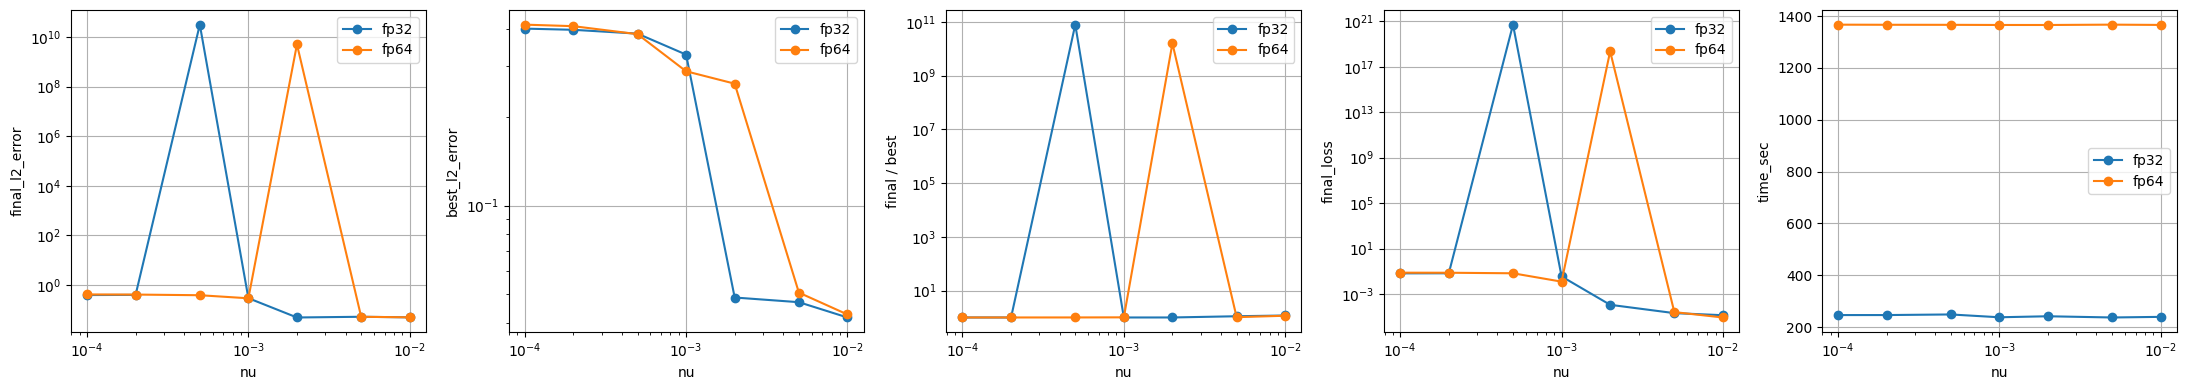

In [7]:
mean_df = df.groupby(["nu", "dtype"])[["final_l2_error", "best_l2_error", "l2_ratio", "final_loss", "time_sec"]].mean().reset_index()

fig, ax = plt.subplots(1, 5, figsize=(22, 4))

for dtype in dtype_values:
    part = mean_df[mean_df["dtype"] == dtype].sort_values("nu")
    ax[0].plot(part["nu"], part["final_l2_error"], "o-", label=dtype)
    ax[1].plot(part["nu"], part["best_l2_error"], "o-", label=dtype)
    ax[2].plot(part["nu"], part["l2_ratio"], "o-", label=dtype)
    ax[3].plot(part["nu"], part["final_loss"], "o-", label=dtype)
    ax[4].plot(part["nu"], part["time_sec"], "o-", label=dtype)

for a in ax:
    a.set_xscale("log")
    a.grid(True)
    a.set_xlabel("nu")
    a.legend()

ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[2].set_yscale("log")
ax[3].set_yscale("log")
ax[0].set_ylabel("final_l2_error")
ax[1].set_ylabel("best_l2_error")
ax[2].set_ylabel("final / best")
ax[3].set_ylabel("final_loss")
ax[4].set_ylabel("time_sec")

fig.tight_layout()
plt.show()

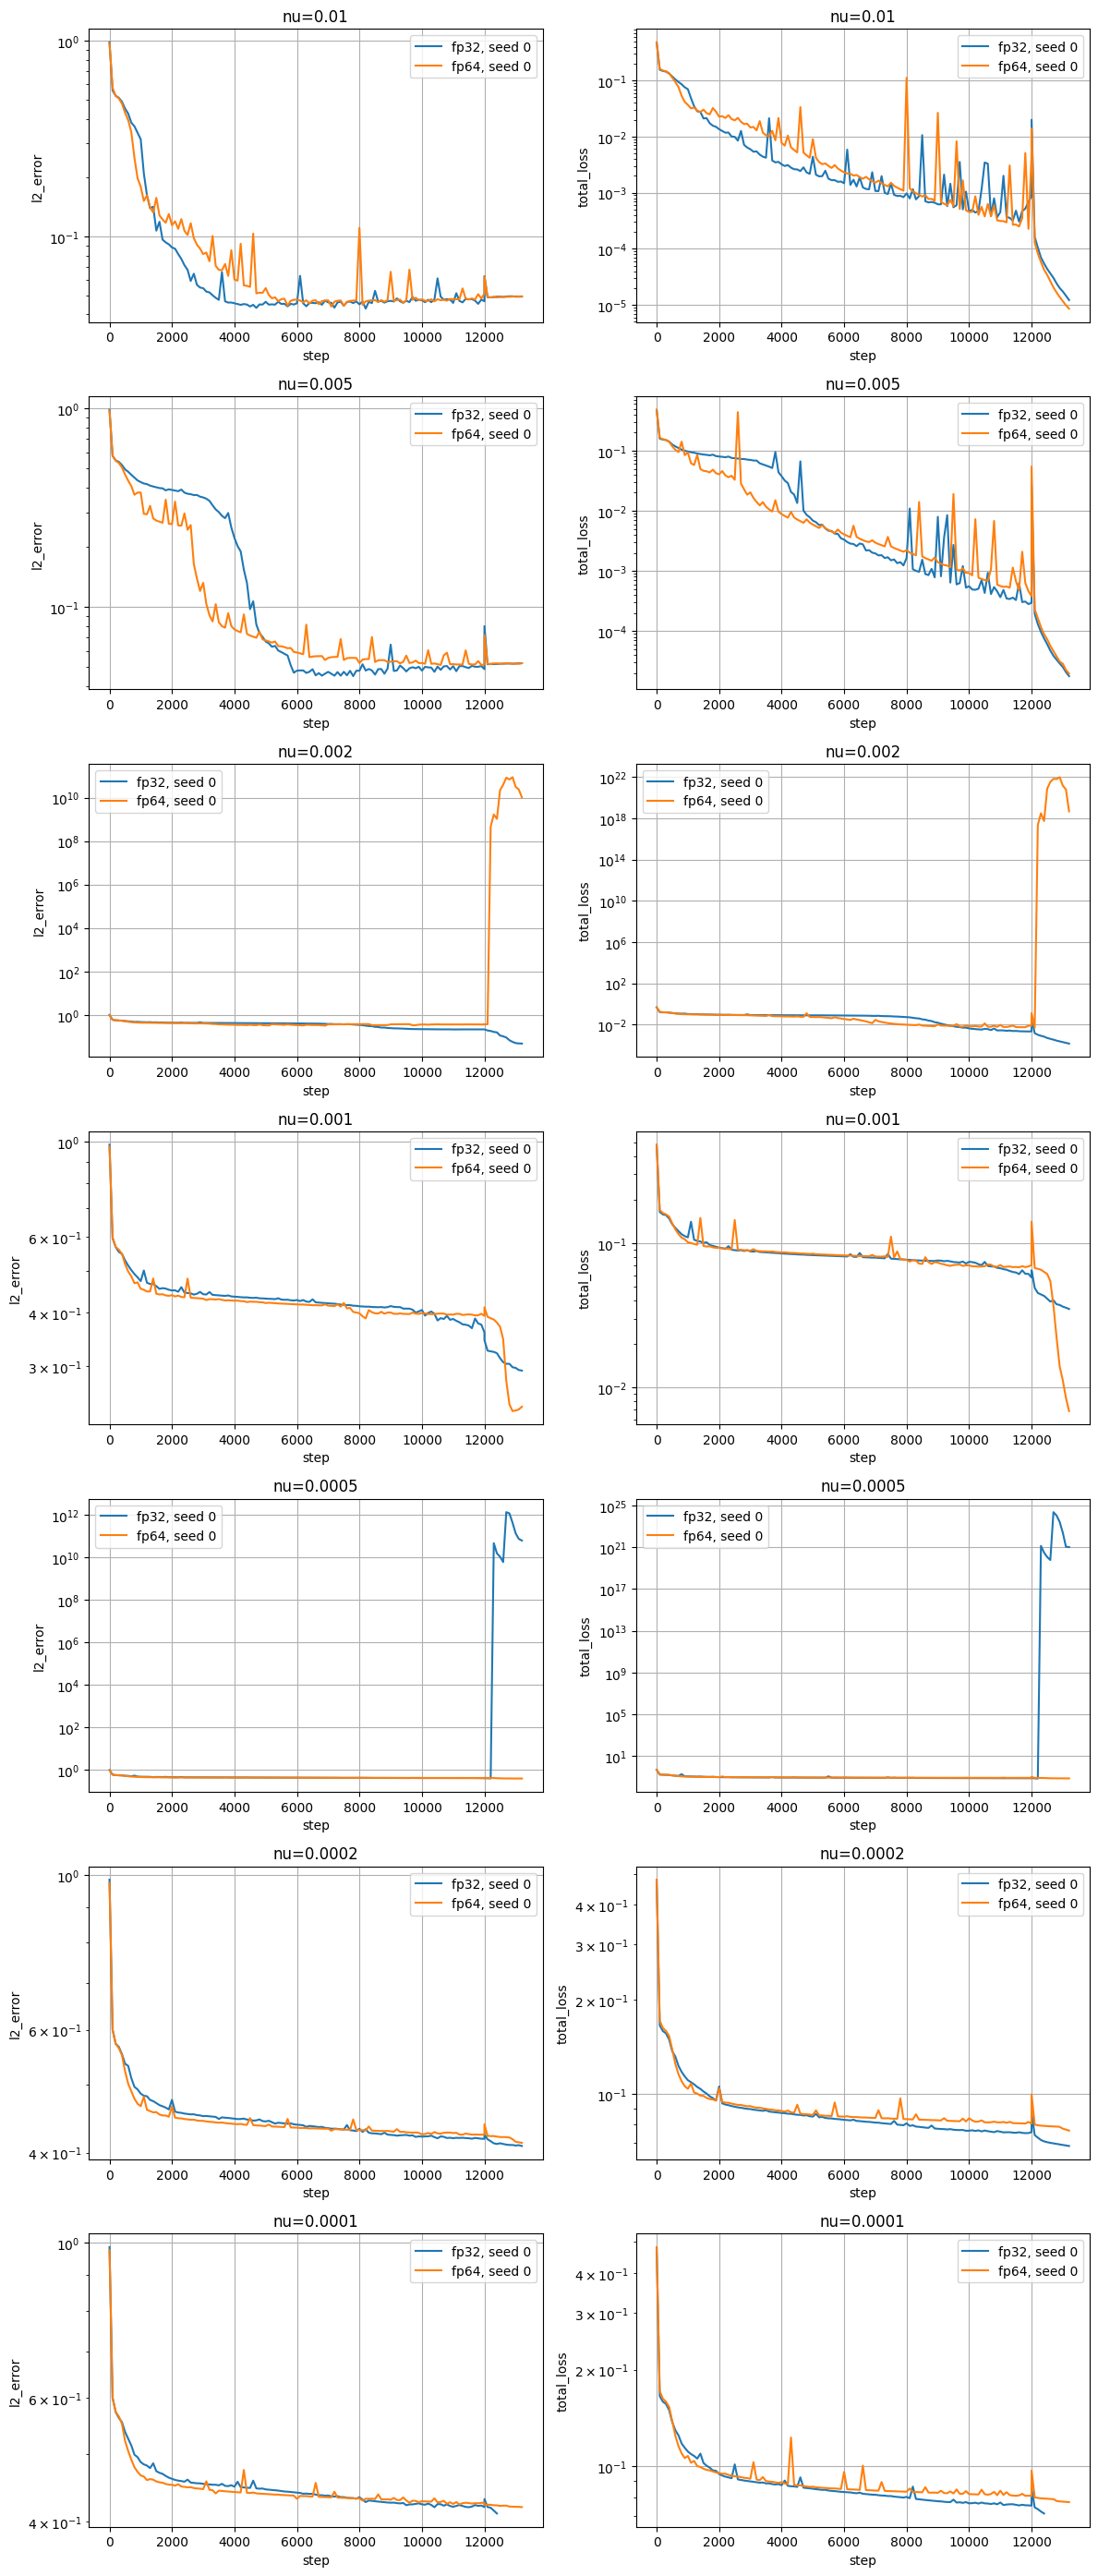

In [8]:
fig, ax = plt.subplots(len(nu_values), 2, figsize=(12, 4 * len(nu_values)))
ax = np.array(ax).reshape(len(nu_values), 2)

for i, nu in enumerate(nu_values):
    nu_tag = make_nu_tag(nu)
    for dtype in dtype_values:
        seed = seed_values[0]
        p = work_dir / "runs" / f"burgers_hard_nu_{nu_tag}_{dtype}_{seed}" / "metrics.csv"
        if p.exists():
            h = pd.read_csv(p)
            label = f"{dtype}, seed {seed}"
            ax[i, 0].plot(h["step"], h["l2_error"], label=label)
            ax[i, 1].plot(h["step"], h["total_loss"], label=label)

    ax[i, 0].set_title(f"nu={nu:g}")
    ax[i, 1].set_title(f"nu={nu:g}")
    ax[i, 0].set_yscale("log")
    ax[i, 1].set_yscale("log")
    ax[i, 0].set_xlabel("step")
    ax[i, 1].set_xlabel("step")
    ax[i, 0].set_ylabel("l2_error")
    ax[i, 1].set_ylabel("total_loss")
    ax[i, 0].grid(True)
    ax[i, 1].grid(True)
    ax[i, 0].legend()
    ax[i, 1].legend()

fig.tight_layout()
plt.show()

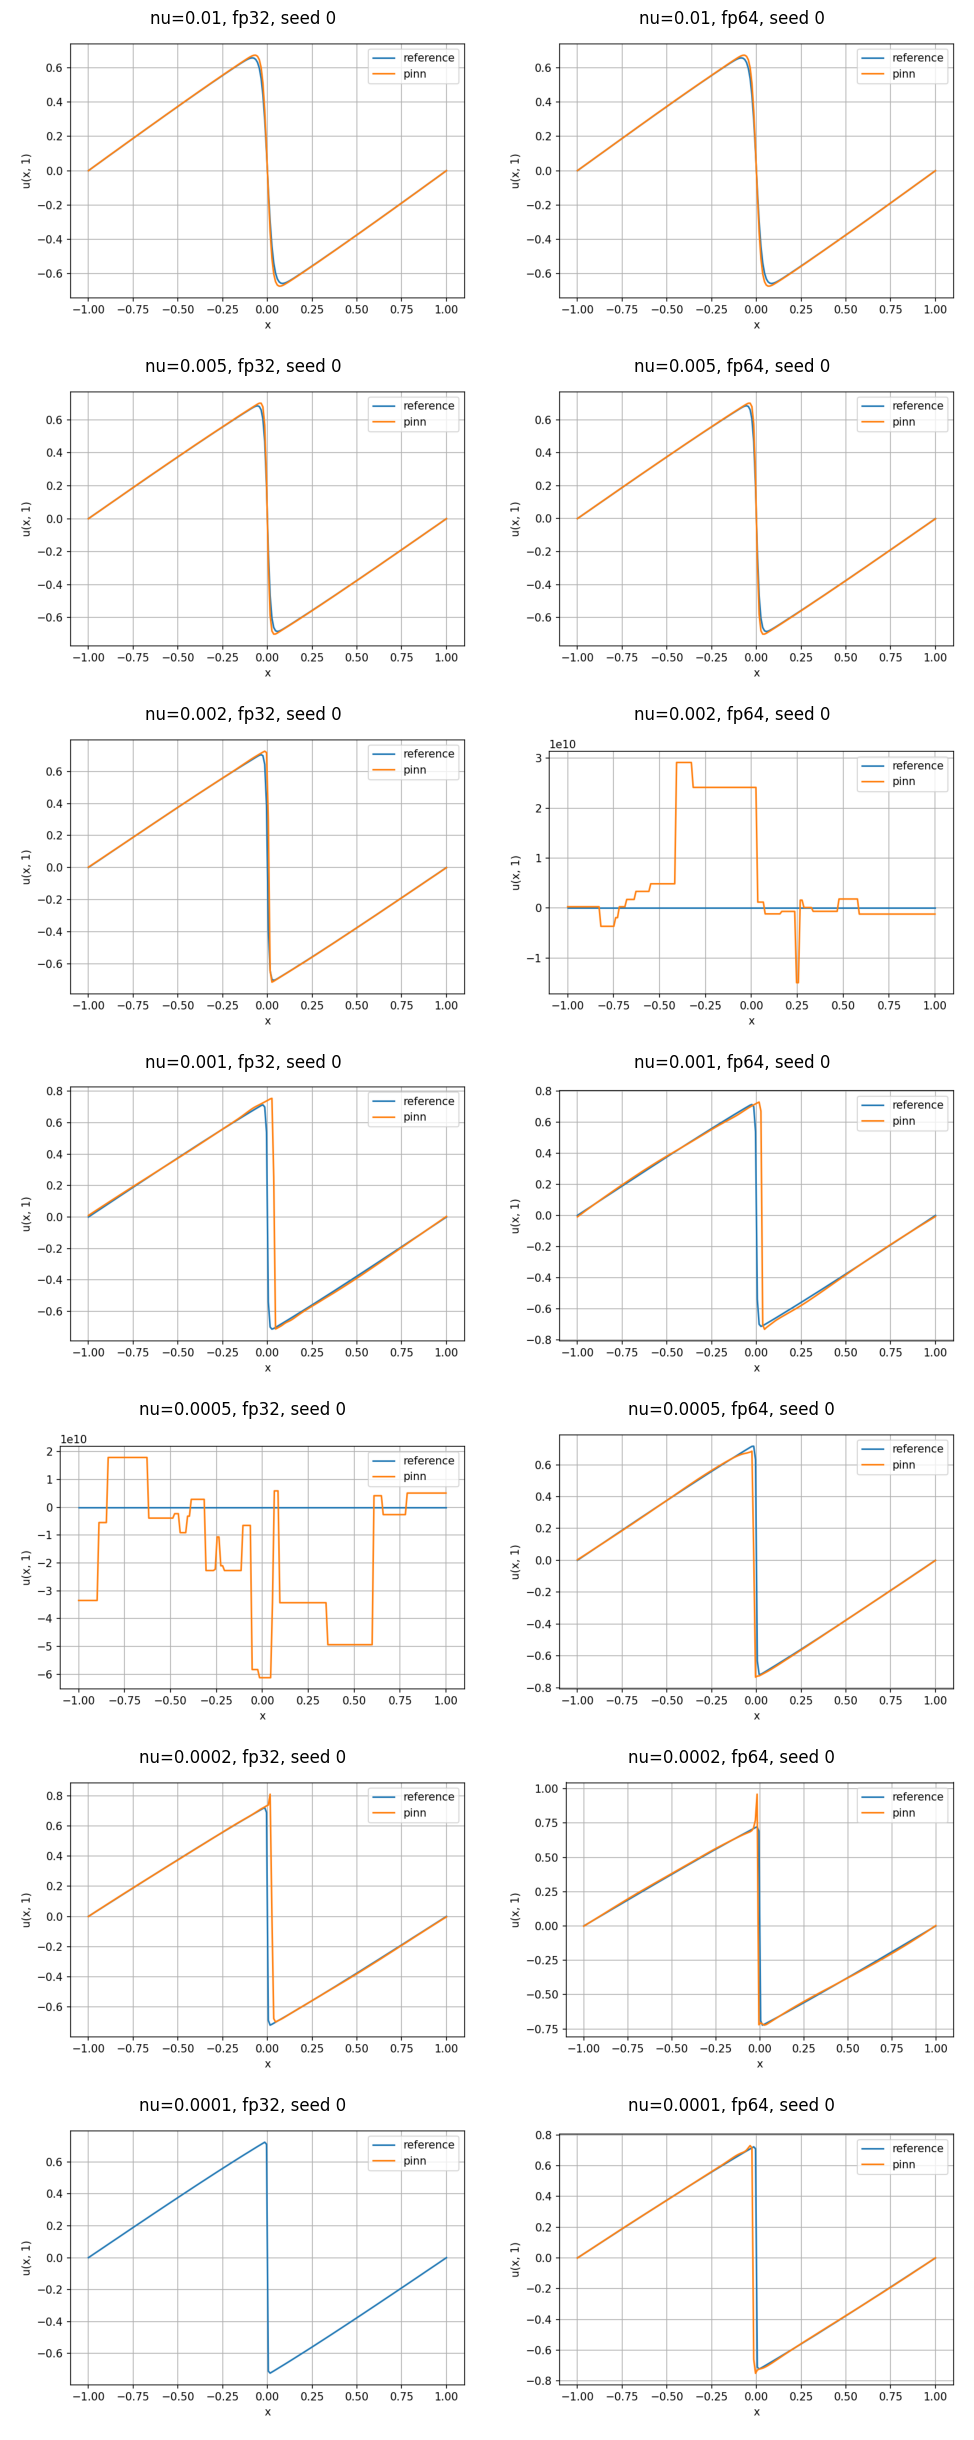

In [9]:
fig, ax = plt.subplots(len(nu_values), len(dtype_values), figsize=(5 * len(dtype_values), 3.5 * len(nu_values)))
ax = np.array(ax).reshape(len(nu_values), len(dtype_values))

for i, nu in enumerate(nu_values):
    nu_tag = make_nu_tag(nu)
    for j, dtype in enumerate(dtype_values):
        seed = seed_values[0]
        p = work_dir / "runs" / f"burgers_hard_nu_{nu_tag}_{dtype}_{seed}" / "solution_t1.png"
        ax[i, j].set_title(f"nu={nu:g}, {dtype}, seed {seed}")
        ax[i, j].axis("off")
        if p.exists():
            img = plt.imread(p)
            ax[i, j].imshow(img)

fig.tight_layout()
plt.show()